# 07. Feature Engineering — 고객 이탈 예측
customer_churn_raw.csv를 분석하고 이탈 예측을 위한 파생 피처를 생성합니다.

* 피처 엔지니어링의 전체 범위
                                                                                                                
- 피처 엔지니어링은 "모델이 학습하기 좋은 형태로 데이터를 가공하는 모든 작업" 입니다.  
~~~                           
  
  ┌────────────────┬─────────────────────────┬────────────────────┐
  │      작업      │          예시           │     필수 여부      │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 결측값 처리    │ 평균 대체, 삭제         │ 거의 필수          │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 인코딩         │ One-hot, Label encoding │ 범주형 있으면 필수 │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 스케일링       │ StandardScaler, MinMax  │ 모델에 따라 필수   │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 이상치 처리    │ 클리핑, 로그 변환       │ 데이터에 따라      │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 파생 피처 생성 │ 비율, 플래그, 상호작용  │ 선택               │
  ├────────────────┼─────────────────────────┼────────────────────┤
  │ 피처 선택      │ 중요도 낮은 피처 제거   │ 선택               │
  └────────────────┴─────────────────────────┴────────────────────┘
~~~

파생 피쳐가 유용한 경우

  - 원본 피쳐만으로 패턴 포착이 어려울 때 (예: tenure × monthly_spend → 고객 가치)
  - 도메인 지식으로 의미 있는 조합이 명확할 때
  - 선형 모델처럼 비선형 관계를 스스로 학습 못하는 모델을 쓸 때

  파생 피쳐가 불필요한 경우

  - 트리 기반 모델(XGBoost, Random Forest)은 피쳐 간 상호작용을 자체적으로 학습
  - 데이터가 이미 충분히 표현력 있을 때
  - 파생 피쳐가 오히려 다중공선성 문제를 일으킬 때

  결론: 데이터 정제·인코딩·스케일링이 핵심이고, 파생 피쳐는 모델 성능을 더 끌어올리기 위한 선택적 기법입니다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
font_path = r'C:\Windows\Fonts\malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv(r'..\resources\customer_churn_raw.csv')
print(f'데이터 크기: {df.shape}')
df.head()

데이터 크기: (100, 11)


,customer_id,age,tenure_months,monthly_spend,num_products,num_support_tickets,last_login_days_ago,contract_type,payment_method,region,churned
0,C001,34,12,125.50,2,3,5,Monthly,Credit Card,North,1
1,C002,28,48,350.00,5,1,2,Annual,Bank Transfer,South,0
2,C003,45,6,85.75,1,8,45,Monthly,PayPal,East,1
3,C004,31,36,220.00,3,2,8,Annual,Credit Card,West,0
4,C005,52,60,450.00,5,0,1,Annual,Bank Transfer,North,0


## 1. 기존 피처와 이탈 타겟 간 관계 분석

In [2]:
# 수치형 피처의 이탈 여부별 평균 비교
numeric_cols = ['age', 'tenure_months', 'monthly_spend', 'num_products',
                'num_support_tickets', 'last_login_days_ago']

print('=== 이탈 여부별 수치형 피처 평균 ===' )
print(df.groupby('churned')[numeric_cols].mean().round(2).T)

print('\n=== 범주형 피처별 이탈률 ===')
for col in ['contract_type', 'payment_method', 'region']:
    print(f'\n[{col}]')
    print(df.groupby(col)['churned'].mean().round(3))

=== 이탈 여부별 수치형 피처 평균 ===
churned                   0       1
age                   41.90   32.57
tenure_months         41.65   11.96
monthly_spend        327.71  130.34
num_products           4.08    2.12
num_support_tickets    1.22    5.82
last_login_days_ago    7.96   47.45

=== 범주형 피처별 이탈률 ===

[contract_type]
contract_type
Annual     0.0
Monthly    1.0
Name: churned, dtype: float64

[payment_method]
payment_method
Bank Transfer    0.355
Credit Card      0.575
PayPal           0.586
Name: churned, dtype: float64

[region]
region
East     0.20
North    0.48
South    0.64
West     0.72
Name: churned, dtype: float64


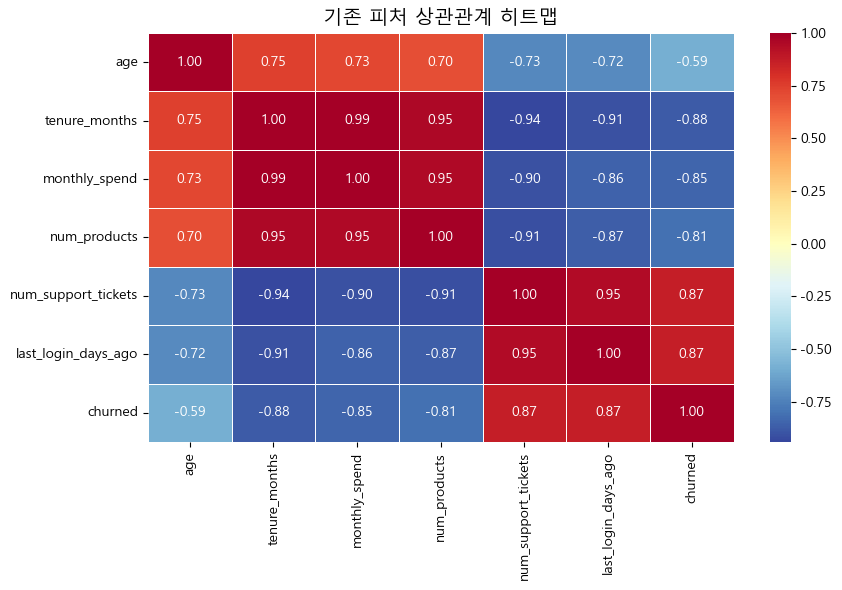

저장: 01_original_feature_correlation.png


In [3]:
# 기존 수치형 피처와 이탈 타겟의 상관관계 히트맵
fig, ax = plt.subplots(figsize=(9, 6))

corr_cols = numeric_cols + ['churned']
corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('기존 피처 상관관계 히트맵', fontsize=14)
plt.tight_layout()
plt.savefig(r'..\output\01_original_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_original_feature_correlation.png')

## 2. 파생 피처 생성 (8개 이상)

### [A] 비율(Ratio) 및 상호작용(Interaction) 피처

In [4]:
df_eng = df.copy()

# 피처 1: 제품당 월 지출 — 활용도 대비 지출 수준을 나타냄
# 낮을수록 단일 제품에 의존 or 저활용 → 이탈 위험 높음
df_eng['spend_per_product'] = df_eng['monthly_spend'] / df_eng['num_products']

# 피처 2: 재직기간 대비 지원 요청 비율 — 만족도의 역지표
# 짧은 기간에 문의가 많으면 제품 불만족 신호
df_eng['support_rate'] = df_eng['num_support_tickets'] / (df_eng['tenure_months'] + 1)

# 피처 3: 상대적 비활성도 — 재직기간 대비 미접속 기간
# 장기 고객이 오래 안 들어올수록 이탈 임박 신호
df_eng['relative_inactivity'] = df_eng['last_login_days_ago'] / (df_eng['tenure_months'] + 1)

# 피처 4: 나이 × 재직기간 상호작용 — 젊고 짧은 고객 vs 나이 들고 오래된 고객
df_eng['age_tenure_interaction'] = df_eng['age'] * df_eng['tenure_months']

print('비율/상호작용 피처 생성 완료')
df_eng[['spend_per_product','support_rate','relative_inactivity','age_tenure_interaction']].describe().round(2)

비율/상호작용 피처 생성 완료


,spend_per_product,support_rate,relative_inactivity,age_tenure_interaction
count,100.00,100.00,100.00,100.00
mean,71.70,0.35,2.87,1084.51
std,13.98,0.50,4.33,832.60
min,47.50,0.00,0.02,56.00
25%,59.75,0.02,0.17,324.50
50%,71.92,0.15,0.84,905.00
75%,82.88,0.50,5.02,1748.25
max,105.19,3.00,26.67,3120.00


### [B] 행동 지표 (Behavioral Indicators)

In [5]:
# 피처 5: 종합 참여 점수 — 제품 수와 최근 접속을 결합한 실사용 강도
# 제품을 많이 쓰고 최근에 접속할수록 점수 높음
df_eng['engagement_score'] = df_eng['num_products'] / (df_eng['last_login_days_ago'] + 1)

# 피처 6: 고객 생애 가치 근사값 — 재직기간 × 월 지출
# 이탈 시 손실 규모를 나타내는 지표
df_eng['lifetime_value_proxy'] = df_eng['tenure_months'] * df_eng['monthly_spend']

print('행동 지표 피처 생성 완료')
df_eng[['engagement_score','lifetime_value_proxy']].describe().round(2)

행동 지표 피처 생성 완료


,engagement_score,lifetime_value_proxy
count,100.00,100.00
mean,0.38,7972.87
std,0.51,8017.68
min,0.01,181.50
25%,0.04,1360.38
50%,0.15,4233.50
75%,0.50,14050.00
max,2.50,27840.00


### [C] 임계값 기반 위험 플래그 (Risk Flags)

In [6]:
# 피처 7: 높은 지원 요청 플래그 — 5건 이상이면 불만 고객으로 분류
df_eng['high_support_flag'] = (df_eng['num_support_tickets'] >= 5).astype(int)

# 피처 8: 장기 미접속 플래그 — 30일 이상 미접속 = 이탈 직전 신호
df_eng['inactive_flag'] = (df_eng['last_login_days_ago'] >= 30).astype(int)

# 피처 9: 신규 고객 플래그 — 재직 6개월 이하, 초기 이탈 위험 구간
df_eng['low_tenure_flag'] = (df_eng['tenure_months'] <= 6).astype(int)

print('위험 플래그 피처 생성 완료')
print('high_support_flag 분포:', df_eng['high_support_flag'].value_counts().to_dict())
print('inactive_flag 분포:    ', df_eng['inactive_flag'].value_counts().to_dict())
print('low_tenure_flag 분포:  ', df_eng['low_tenure_flag'].value_counts().to_dict())

위험 플래그 피처 생성 완료
high_support_flag 분포: {0: 62, 1: 38}
inactive_flag 분포:     {0: 54, 1: 46}
low_tenure_flag 분포:   {0: 89, 1: 11}


### [D] SaaS 도메인 특화 피처

In [7]:
# 피처 10: 월정액 계약 플래그 — 연간 대비 월정액은 해지 장벽이 낮음
df_eng['monthly_contract_flag'] = (df_eng['contract_type'] == 'Monthly').astype(int)

# 피처 11: 복합 위험 점수 — 위험 플래그 합산으로 다중 위험 신호 포착
df_eng['risk_score'] = (df_eng['high_support_flag'] +
                        df_eng['inactive_flag'] +
                        df_eng['low_tenure_flag'] +
                        df_eng['monthly_contract_flag'])

print('SaaS 도메인 피처 생성 완료')
print('monthly_contract_flag 분포:', df_eng['monthly_contract_flag'].value_counts().to_dict())
print('risk_score 분포:\n', df_eng['risk_score'].value_counts().sort_index())

SaaS 도메인 피처 생성 완료
monthly_contract_flag 분포: {1: 51, 0: 49}
risk_score 분포:
 risk_score
0    49
1     4
2    10
3    26
4    11
Name: count, dtype: int64


## 3. 각 파생 피처의 예측 유효성 설명

In [8]:
feature_explanations = {
    'spend_per_product':       '제품당 지출이 낮으면 활용도가 낮아 이탈 가능성 증가',
    'support_rate':            '재직기간 대비 문의 빈도가 높으면 제품 불만족 신호',
    'relative_inactivity':     '재직기간 대비 미접속 기간이 길수록 이탈 임박',
    'age_tenure_interaction':  '나이×재직기간 조합으로 고객 생애주기 단계 포착',
    'engagement_score':        '제품 수와 접속 빈도를 결합한 실제 사용 강도',
    'lifetime_value_proxy':    '재직기간×월지출로 잠재 손실 규모 추정',
    'high_support_flag':       '5건 이상 문의 → 강성 불만 고객 이진 분류',
    'inactive_flag':           '30일 이상 미접속 → 이탈 직전 행동 패턴',
    'low_tenure_flag':         '6개월 이하 → 초기 이탈 위험 구간 명시',
    'monthly_contract_flag':   '월정액은 연간 대비 해지 장벽이 낮아 이탈률 높음',
    'risk_score':              '복수 위험 신호 누적 시 이탈 확률 급증 포착',
}

print('=== 파생 피처 예측 유효성 ===')
for feat, reason in feature_explanations.items():
    print(f'  {feat:<28}: {reason}')

=== 파생 피처 예측 유효성 ===
  spend_per_product           : 제품당 지출이 낮으면 활용도가 낮아 이탈 가능성 증가
  support_rate                : 재직기간 대비 문의 빈도가 높으면 제품 불만족 신호
  relative_inactivity         : 재직기간 대비 미접속 기간이 길수록 이탈 임박
  age_tenure_interaction      : 나이×재직기간 조합으로 고객 생애주기 단계 포착
  engagement_score            : 제품 수와 접속 빈도를 결합한 실제 사용 강도
  lifetime_value_proxy        : 재직기간×월지출로 잠재 손실 규모 추정
  high_support_flag           : 5건 이상 문의 → 강성 불만 고객 이진 분류
  inactive_flag               : 30일 이상 미접속 → 이탈 직전 행동 패턴
  low_tenure_flag             : 6개월 이하 → 초기 이탈 위험 구간 명시
  monthly_contract_flag       : 월정액은 연간 대비 해지 장벽이 낮아 이탈률 높음
  risk_score                  : 복수 위험 신호 누적 시 이탈 확률 급증 포착


## 4. 파생 피처와 이탈 타겟 간 상관관계

In [9]:
new_features = list(feature_explanations.keys())

# 각 파생 피처와 churned의 상관계수
corr_with_churn = df_eng[new_features + ['churned']].corr()['churned'].drop('churned')

print('=== 파생 피처 vs 이탈 타겟 상관계수 (내림차순) ===')
print(corr_with_churn.abs().sort_values(ascending=False).round(4))

=== 파생 피처 vs 이탈 타겟 상관계수 (내림차순) ===
monthly_contract_flag     1.0000
risk_score                0.9221
inactive_flag             0.9047
age_tenure_interaction    0.8250
lifetime_value_proxy      0.7992
high_support_flag         0.7674
engagement_score          0.6544
support_rate              0.6238
relative_inactivity       0.6017
spend_per_product         0.5633
low_tenure_flag           0.3446
Name: churned, dtype: float64


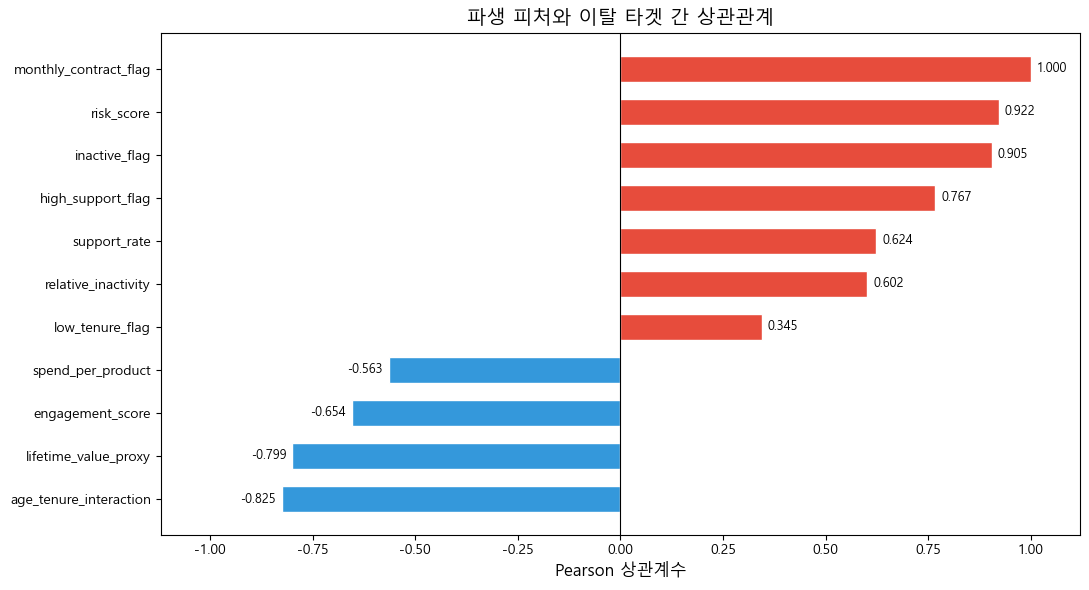

저장: 02_engineered_feature_correlation.png


In [10]:
# 파생 피처 상관관계 막대 차트
fig, ax = plt.subplots(figsize=(11, 6))

sorted_corr = corr_with_churn.sort_values()
colors = ['#e74c3c' if v > 0 else '#3498db' for v in sorted_corr]

ax.barh(sorted_corr.index, sorted_corr.values, color=colors, edgecolor='white', height=0.6)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson 상관계수', fontsize=12)
ax.set_title('파생 피처와 이탈 타겟 간 상관관계', fontsize=14)

# 실제 값 범위에 레이블 여백(0.12)을 더해 xlim 자동 설정 — 하드코딩 제거
max_abs = sorted_corr.abs().max()
ax.set_xlim(-(max_abs + 0.12), max_abs + 0.12)

# 레이블: 음수는 바 왼쪽 바깥, 양수는 바 오른쪽 바깥 (겹침 방지)
offset = 0.015
for i, v in enumerate(sorted_corr.values):
    if v >= 0:
        ax.text(v + offset, i, f'{v:.3f}', va='center', ha='left', fontsize=9)
    else:
        ax.text(v - offset, i, f'{v:.3f}', va='center', ha='right', fontsize=9)

plt.tight_layout()
plt.savefig(r'..\output\02_engineered_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_engineered_feature_correlation.png')

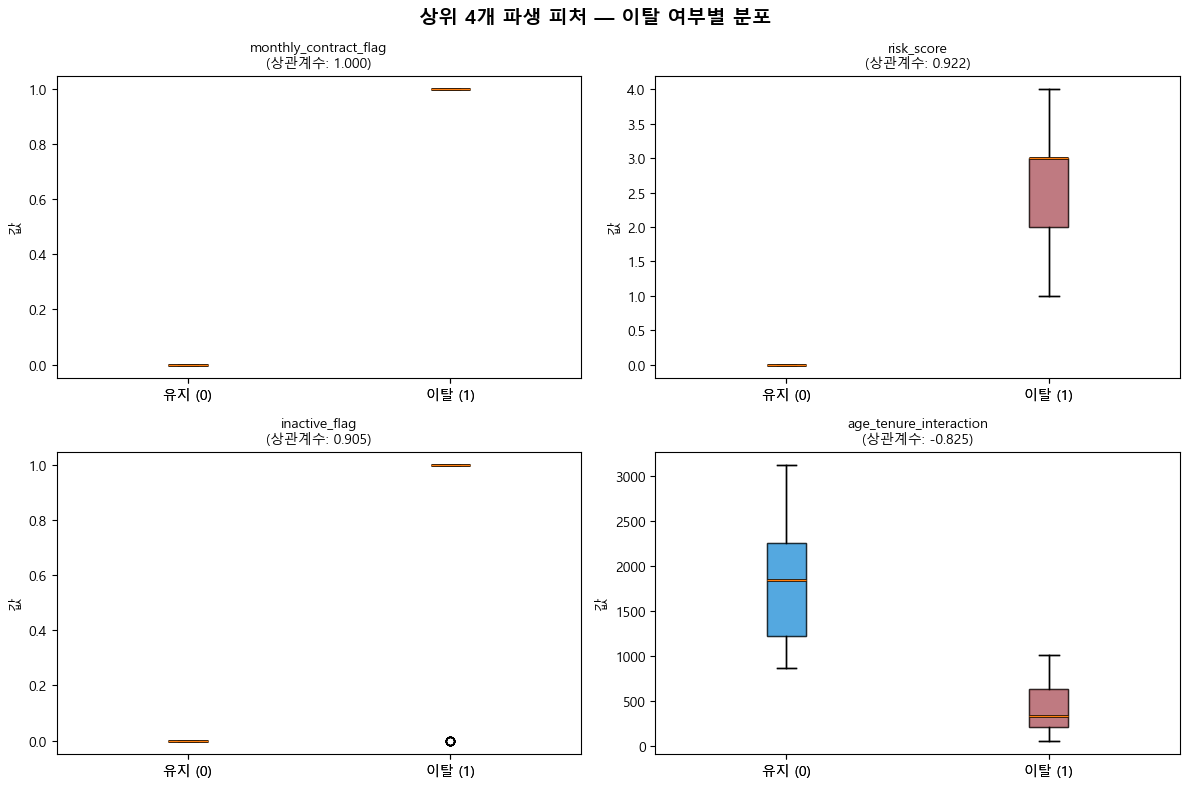

저장: 03_top_features_boxplot.png


In [11]:
# 상위 4개 파생 피처의 이탈 여부별 분포 박스플롯
top4 = corr_with_churn.abs().sort_values(ascending=False).head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feat in enumerate(top4):
    ax = axes[i]
    churned_0 = df_eng[df_eng['churned'] == 0][feat]
    churned_1 = df_eng[df_eng['churned'] == 1][feat]

    ax.boxplot([churned_0, churned_1], labels=['유지 (0)', '이탈 (1)'],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    # 이탈 박스를 빨간색으로 강조
    bp = ax.boxplot([churned_0, churned_1], labels=['유지 (0)', '이탈 (1)'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][1].set_alpha(0.6)

    ax.set_title(f'{feat}\n(상관계수: {corr_with_churn[feat]:.3f})', fontsize=10)
    ax.set_ylabel('값')

fig.suptitle('상위 4개 파생 피처 — 이탈 여부별 분포', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'..\output\03_top_features_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_top_features_boxplot.png')

## 5. 범주형 피처 인코딩 및 최종 데이터셋 저장

In [12]:
# 범주형 변수를 원-핫 인코딩 (ML 파이프라인 바로 사용 가능하도록)
df_final = pd.get_dummies(df_eng,
                          columns=['contract_type', 'payment_method', 'region'],
                          drop_first=False)

# customer_id는 식별자이므로 제거
df_final = df_final.drop(columns=['customer_id'])

print(f'최종 데이터셋 크기: {df_final.shape}')
print(f'생성된 피처 수: {df_final.shape[1] - 1} (churned 제외)')
print(f'이탈 비율: {df_final["churned"].mean():.2%}')

# 저장
output_path = r'..\resources\customer_churn_engineered.csv'
df_final.to_csv(output_path, index=False)
print(f'\n저장 완료: {output_path}')
df_final.head()

최종 데이터셋 크기: (100, 27)
생성된 피처 수: 26 (churned 제외)
이탈 비율: 51.00%

저장 완료: ..\resources\customer_churn_engineered.csv


,age,tenure_months,monthly_spend,num_products,num_support_tickets,last_login_days_ago,churned,spend_per_product,support_rate,relative_inactivity,...,risk_score,contract_type_Annual,contract_type_Monthly,payment_method_Bank Transfer,payment_method_Credit Card,payment_method_PayPal,region_East,region_North,region_South,region_West
0,34,12,125.50,2,3,5,1,62.750000,0.230769,0.384615,...,1,False,True,False,True,False,False,True,False,False
1,28,48,350.00,5,1,2,0,70.000000,0.020408,0.040816,...,0,True,False,True,False,False,False,False,True,False
2,45,6,85.75,1,8,45,1,85.750000,1.142857,6.428571,...,4,False,True,False,False,True,True,False,False,False
3,31,36,220.00,3,2,8,0,73.333333,0.054054,0.216216,...,0,True,False,False,True,False,False,False,False,True
4,52,60,450.00,5,0,1,0,90.000000,0.000000,0.016393,...,0,True,False,True,False,False,False,True,False,False


In [13]:
# 최종 요약
print('=== 피처 엔지니어링 완료 요약 ===')
print(f'원본 피처 수  : {len(numeric_cols) + 3} (수치형 {len(numeric_cols)} + 범주형 3)')
print(f'파생 피처 수  : {len(new_features)}')
print(f'최종 피처 수  : {df_final.shape[1] - 1}')
print()
print('이탈과 가장 높은 상관관계 피처 Top 5:')
all_corr = df_final.corr()['churned'].drop('churned').abs().sort_values(ascending=False)
print(all_corr.head(5).round(4))

=== 피처 엔지니어링 완료 요약 ===
원본 피처 수  : 9 (수치형 6 + 범주형 3)
파생 피처 수  : 11
최종 피처 수  : 26

이탈과 가장 높은 상관관계 피처 Top 5:
contract_type_Monthly    1.0000
monthly_contract_flag    1.0000
contract_type_Annual     1.0000
risk_score               0.9221
inactive_flag            0.9047
Name: churned, dtype: float64
